
# Home Credit Default Risk — Predictive Modeling

This notebook builds a machine learning pipeline to predict loan default risk.

Pipeline:
1. Load datasets
2. Feature engineering
3. Train/validation split
4. LightGBM model
5. Evaluation using ROC-AUC
6. Feature importance analysis


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

from lightgbm import LGBMClassifier


## Load Data

In [2]:
base_path="./data/"
train = pd.read_csv(f"{base_path}application_train.csv")
bureau = pd.read_csv(f"{base_path}bureau.csv")
previous = pd.read_csv(f"{base_path}previous_application.csv")
installments = pd.read_csv(f"{base_path}installments_payments.csv")

print(train.shape)
train.head()


(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Engineering

In [3]:

train["AGE"] = -train["DAYS_BIRTH"] / 365

train["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
train["EMPLOYMENT_YEARS"] = -train["DAYS_EMPLOYED"] / 365

train["CREDIT_INCOME_RATIO"] = train["AMT_CREDIT"] / train["AMT_INCOME_TOTAL"]
train["ANNUITY_INCOME_RATIO"] = train["AMT_ANNUITY"] / train["AMT_INCOME_TOTAL"]
train["CREDIT_GOODS_RATIO"] = train["AMT_CREDIT"] / train["AMT_GOODS_PRICE"]

train["EXT_SOURCE_MEAN"] = train[
    ["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]
].mean(axis=1)


/tmp/ipykernel_26906/3393224644.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)


## Installment Features

In [4]:

installments["PAYMENT_DELAY"] = (
    installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
)

delay_mean = installments.groupby("SK_ID_CURR")["PAYMENT_DELAY"].mean()

train = train.merge(
    delay_mean.rename("MEAN_PAYMENT_DELAY"),
    on="SK_ID_CURR",
    how="left"
)


## Bureau Features

In [5]:

bureau_count = bureau.groupby("SK_ID_CURR").size()

train = train.merge(
    bureau_count.rename("BUREAU_LOAN_COUNT"),
    on="SK_ID_CURR",
    how="left"
)


## Encode Categorical Variables

In [6]:

for col in train.select_dtypes("object").columns:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))


## Prepare Training Data

In [7]:

target = train["TARGET"]
features = train.drop(columns=["TARGET","SK_ID_CURR"])

features = features.fillna(features.median())


## Train / Validation Split

In [8]:

X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)


## Train LightGBM Model

In [9]:

model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13070
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 123
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Evaluation

In [10]:

preds = model.predict_proba(X_valid)[:,1]

auc = roc_auc_score(y_valid, preds)

print("Validation ROC-AUC:", auc)


Validation ROC-AUC: 0.760760685540592


## Feature Importance

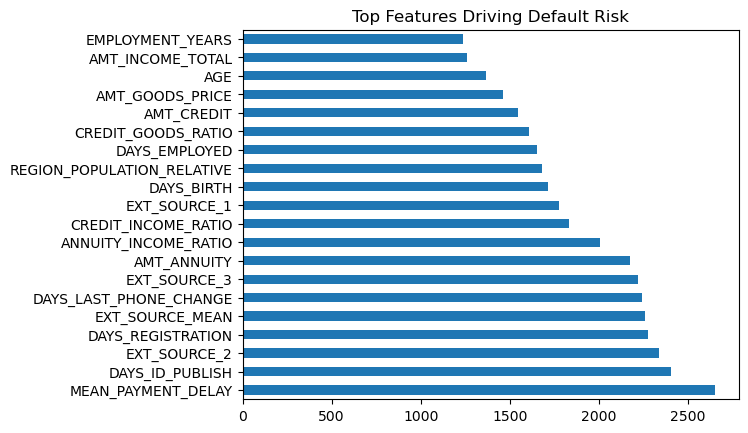

In [11]:

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(20).plot(kind="barh")

plt.title("Top Features Driving Default Risk")

plt.show()



## Interpretation

Typical important predictors include:
- External credit scores
- Credit-to-income ratio
- Loan payment burden
- Borrower age
- Employment stability
